# Compatibilidad musical entre dos usuarios

A partir de las canciones de dos usuarios se calcula un score de compatibilidad,
el cluster en el que cae cada uno y canciones "puente" para una playlist conjunta.
Los perfiles se simulan con géneros del dataset; se podrían reemplazar con datos
reales del API de Spotify.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "user_compatibility":
    PROJECT_ROOT = PROJECT_ROOT.parent

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv")
df = df.reset_index(drop=True)

print(f"{df.shape[0]:,} canciones, {df['track_genre'].nunique()} géneros")

89,741 canciones, 113 géneros


## Variables de audio

Las mismas que en `06_clustering.ipynb`, para ser consistentes con ese K-Means.

In [3]:
CLUSTER_FEATURES = [
    "duration_min", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

## Perfiles simulados

En producción el perfil saldría del top de canciones del usuario (API de Spotify).
Aquí se simulan dos usuarios con géneros distintos, muestreando canciones reales del dataset.

In [4]:
# Usuario A: géneros urbanos / enérgicos
CANDIDATE_A = ["hip-hop", "pop", "dance", "edm", "electronic", "disco",
               "funk", "r-n-b", "club", "party", "reggaeton", "dancehall"]

# Usuario B: géneros tranquilos / acústicos
CANDIDATE_B = ["acoustic", "classical", "ambient", "chill", "folk", "jazz",
               "new-age", "singer-songwriter", "piano", "study", "sleep"]

genres_a = [g for g in CANDIDATE_A if g in df["track_genre"].values]
genres_b = [g for g in CANDIDATE_B if g in df["track_genre"].values]

N = 50  # canciones por usuario, como un top-50
df_a = df[df["track_genre"].isin(genres_a)].sample(n=N, random_state=RANDOM_STATE)
df_b = df[df["track_genre"].isin(genres_b)].sample(n=N, random_state=RANDOM_STATE + 1)

print(f"Usuario A: {genres_a}")
print(df_a[["track_name", "artists", "track_genre"]].head().to_string(index=False))
print(f"\nUsuario B: {genres_b}")
print(df_b[["track_name", "artists", "track_genre"]].head().to_string(index=False))

Usuario A: ['hip-hop', 'pop', 'dance', 'edm', 'electronic', 'disco', 'funk', 'r-n-b', 'club', 'party', 'reggaeton', 'dancehall']
                                  track_name                                                        artists track_genre
                                 Miłego dnia                                                        Classic       disco
                     Coka 2.0 (From "Liger") Jaani;Lijo George-Dj Chetas;Sukh-E Muzical Doctorz;Lisa Mishra         pop
                              Champagne Talk                                                           King     hip-hop
                                       Fr Fr                                          Wiz Khalifa;Lil Skies       dance
Ihr könnt Euch einfach mal - Walter Wild Mix                    Ikke Hüftgold;Basti Trailerpark;Walter Wild       party

Usuario B: ['acoustic', 'classical', 'ambient', 'chill', 'folk', 'jazz', 'new-age', 'singer-songwriter', 'piano', 'study', 'sleep']
                  

## Perfil de cada usuario

El perfil es el promedio de las variables de audio de sus canciones.

In [5]:
profile_a = df_a[CLUSTER_FEATURES].mean()
profile_b = df_b[CLUSTER_FEATURES].mean()

profiles = pd.DataFrame({
    "Usuario A": profile_a,
    "Usuario B": profile_b
}).round(4)

display(profiles)

,Usuario A,Usuario B
duration_min,3.5416,3.8364
danceability,0.7026,0.4232
energy,0.6994,0.3264
loudness,-6.4249,-16.4937
speechiness,0.1090,0.0569
acousticness,0.2152,0.7086
instrumentalness,0.0502,0.5095
liveness,0.1748,0.1728
valence,0.5968,0.3208
tempo,116.5883,117.1946


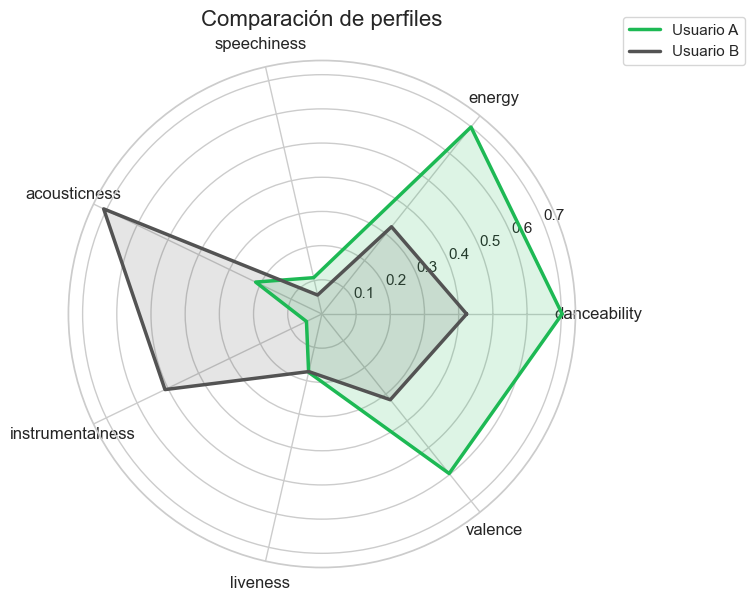

In [6]:
radar_features = ["danceability", "energy", "speechiness", "acousticness",
                  "instrumentalness", "liveness", "valence"]

n = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for col, color in [("Usuario A", "#1DB954"), ("Usuario B", "#535353")]:
    vals = profiles.loc[radar_features, col].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2.5, label=col)
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=12)
ax.set_title("Comparación de perfiles", size=16, pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## Clusters

Se aplica el mismo K-Means (k=2) del notebook 06: un cluster enérgico/bailable
y otro acústico/instrumental.

Usuario A:
cluster
Enérgico / bailable        0.92
Acústico / instrumental    0.08
Name: proportion, dtype: float64

Usuario B:
cluster
Acústico / instrumental    0.76
Enérgico / bailable        0.24
Name: proportion, dtype: float64


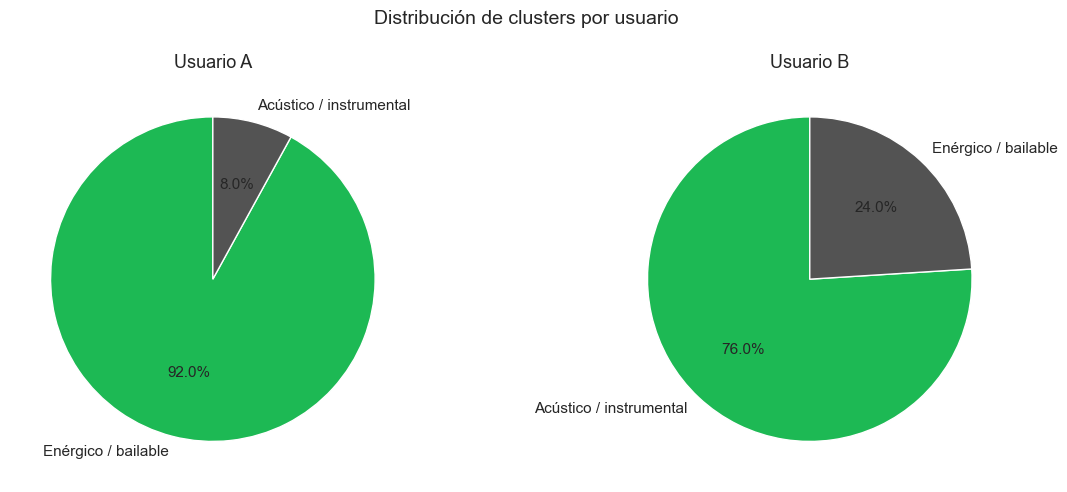

In [7]:
scaler = StandardScaler()
X_all = scaler.fit_transform(df[CLUSTER_FEATURES])

kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_all)

CLUSTER_NAMES = {0: "Enérgico / bailable", 1: "Acústico / instrumental"}

dist_a = df.loc[df_a.index, "cluster"].value_counts(normalize=True).rename(CLUSTER_NAMES)
dist_b = df.loc[df_b.index, "cluster"].value_counts(normalize=True).rename(CLUSTER_NAMES)

print("Usuario A:")
print(dist_a.round(3))
print("\nUsuario B:")
print(dist_b.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#1DB954", "#535353"]

for ax, (dist, title) in zip(axes, [(dist_a, "Usuario A"), (dist_b, "Usuario B")], strict=True):
    ax.pie(dist.values, labels=dist.index, autopct="%1.1f%%",
           colors=colors, startangle=90, textprops={"fontsize": 11})
    ax.set_title(title, fontsize=13)

plt.suptitle("Distribución de clusters por usuario", fontsize=14)
plt.tight_layout()
plt.show()

## Score de compatibilidad

Similitud coseno entre los dos perfiles, normalizada a [0, 1].

In [8]:
vec_a = scaler.transform(profile_a.values.reshape(1, -1))
vec_b = scaler.transform(profile_b.values.reshape(1, -1))

sim = cosine_similarity(vec_a, vec_b)[0][0]
compat = (sim + 1) / 2  # [-1, 1] -> [0, 1]

if compat >= 0.80:
    interp = "Muy alta"
elif compat >= 0.65:
    interp = "Alta"
elif compat >= 0.50:
    interp = "Moderada"
elif compat >= 0.35:
    interp = "Baja"
else:
    interp = "Muy baja"

print(f"Similitud coseno: {sim:.4f}")
print(f"Compatibilidad: {compat:.1%} ({interp})")

Similitud coseno: -0.7816
Compatibilidad: 10.9% (Muy baja)


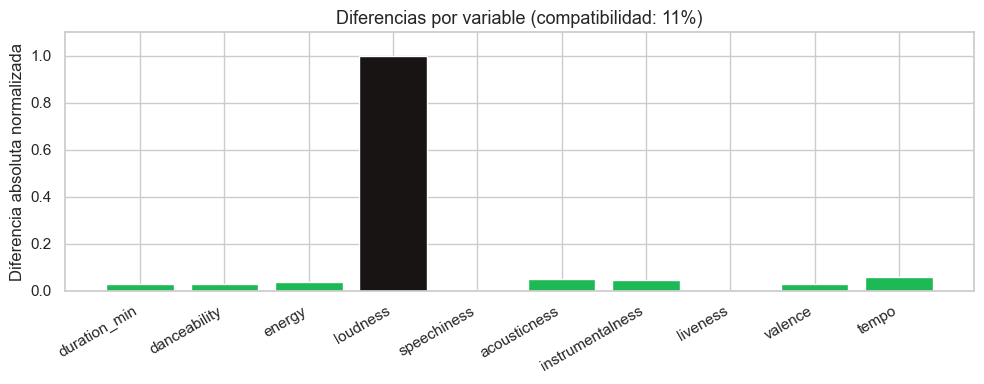

In [9]:
# qué variables separan más a los dos usuarios
diff = (profile_a - profile_b).abs()
diff_norm = diff / diff.max()

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#191414" if v > 0.5 else "#1DB954" for v in diff_norm.values]
ax.bar(diff_norm.index, diff_norm.values, color=bar_colors)
ax.set_title(f"Diferencias por variable (compatibilidad: {compat:.0%})", fontsize=13)
ax.set_ylabel("Diferencia absoluta normalizada")
ax.set_ylim(0, 1.1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Canciones puente

El punto medio de los dos perfiles representa el gusto compartido. Las canciones
más cercanas a ese punto son candidatas para una playlist conjunta.

In [10]:
midpoint_raw = ((profile_a + profile_b) / 2).values.reshape(1, -1)
midpoint_scaled = scaler.transform(midpoint_raw)

dists = np.linalg.norm(X_all - midpoint_scaled, axis=1)
df["dist_midpoint"] = dists

bridge = (
    df.nsmallest(10, "dist_midpoint")[["track_name", "artists", "track_genre", "popularity", "cluster"]]
    .copy()
)
bridge["cluster"] = bridge["cluster"].map(CLUSTER_NAMES)
bridge["popularity"] = bridge["popularity"].astype(int)

display(bridge.reset_index(drop=True))

,track_name,artists,track_genre,popularity,cluster
0,Light Of Day,Anna Ternheim,swedish,0,Enérgico / bailable
1,Let ‘Em In,John Pizzarelli,guitar,22,Enérgico / bailable
2,Smoothie Song,Nickel Creek,bluegrass,21,Acústico / instrumental
3,Rehnuma,Last Minute India,indian,44,Acústico / instrumental
4,散步之年,my little airport,cantopop,29,Acústico / instrumental
5,Just A Closer Walk,Steve Ivey,bluegrass,13,Enérgico / bailable
6,Give a Shit,Greensky Bluegrass,bluegrass,24,Enérgico / bailable
7,Painting Silhouettes,Quantic,trip-hop,57,Acústico / instrumental
8,All Apologies,Nirvana,grunge,60,Enérgico / bailable
9,Harry Houdini,Tomas Andersson Wij,swedish,35,Acústico / instrumental


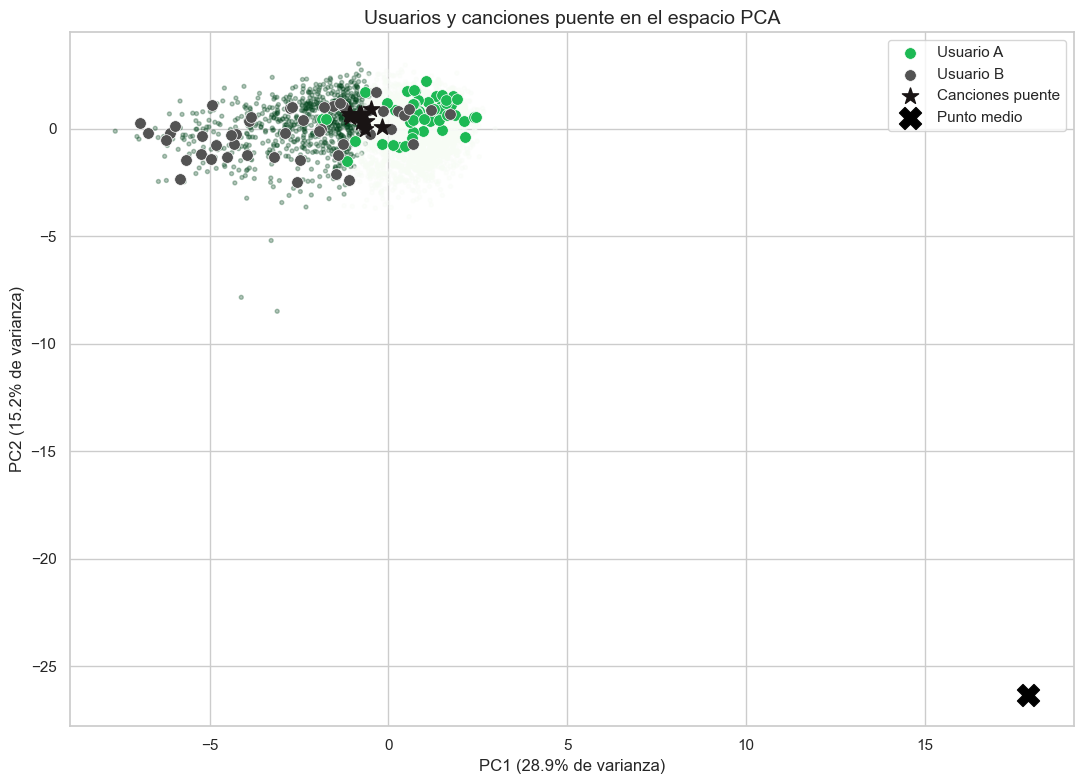

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_all)

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(df), size=3000, replace=False)
bridge_idx = df.nsmallest(10, "dist_midpoint").index.values

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(coords[sample_idx, 0], coords[sample_idx, 1],
           c=df.loc[sample_idx, "cluster"], cmap="Greens",
           alpha=0.3, s=8, label="_")

ax.scatter(coords[df_a.index, 0], coords[df_a.index, 1],
           c="#1DB954", s=70, label="Usuario A", zorder=3,
           edgecolors="white", linewidths=0.5)
ax.scatter(coords[df_b.index, 0], coords[df_b.index, 1],
           c="#535353", s=70, label="Usuario B", zorder=3,
           edgecolors="white", linewidths=0.5)

ax.scatter(coords[bridge_idx, 0], coords[bridge_idx, 1],
           c="#191414", s=150, marker="*", label="Canciones puente", zorder=4)

midpoint_2d = pca.transform(midpoint_raw)
ax.scatter(midpoint_2d[0, 0], midpoint_2d[0, 1],
           c="black", s=250, marker="X", label="Punto medio", zorder=5)

ax.set_title("Usuarios y canciones puente en el espacio PCA", fontsize=14)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} de varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} de varianza)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## API real de Spotify

Con `spotipy` se podrían construir los perfiles con datos reales. El código está
comentado porque requiere credenciales de una app de Spotify Developer; lo demás
del análisis no cambiaría.

In [12]:
# pip install spotipy
#
# import spotipy
# from spotipy.oauth2 import SpotifyOAuth
#
# sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
#     client_id="CLIENT_ID",
#     client_secret="CLIENT_SECRET",
#     redirect_uri="http://localhost:8888/callback",
#     scope="user-top-read user-library-read user-read-recently-played"
# ))
#
# def get_user_audio_profile(sp_client, limit=50, time_range="medium_term"):
#     top = sp_client.current_user_top_tracks(limit=limit, time_range=time_range)
#     ids = [t["id"] for t in top["items"]]
#     features = sp_client.audio_features(ids)
#     feat_df = pd.DataFrame([f for f in features if f is not None])
#     feat_df["duration_min"] = feat_df["duration_ms"] / 60000
#     return feat_df[CLUSTER_FEATURES].mean()
#
# profile_a = get_user_audio_profile(sp_usuario_a)
# profile_b = get_user_audio_profile(sp_usuario_b)